In [11]:
import torch
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from torchvision import transforms
from data_loader.data_loaders import PosterDataset, label_encoding, get_splits, get_dataloader

In [12]:
df = pd.read_csv("../assets/metadata.csv")
label_to_idx, idx_to_label = label_encoding(df)
train_df, val_df, test_df = get_splits(df)

Train: 8 | Val: 1 | Test: 1


In [13]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

In [15]:
loader = get_dataloader(train_df, label_to_idx, transform, batch_size=5, shuffle=True)
images, labels = next(iter(loader))
print(images.shape)

/gpfs/home/khousto4/movie-poster-genre/venv/lib64/python3.11/site-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/gpfs/home/khousto4/movie-poster-genre/venv/lib64/python3.11/site-packages/torch/utils/data/dataloader.py:430: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_

torch.Size([5, 3, 224, 224])


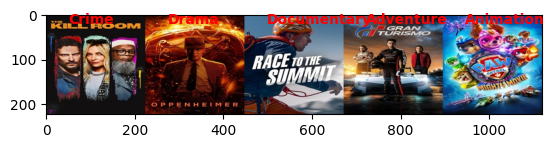

In [17]:
mean = [0.5, 0.5, 0.5]
std = [0.5, 0.5, 0.5]

plot_images = images * torch.tensor(std).view(1,3,1,1) + torch.tensor(mean).view(1,3,1,1)
plot_images = (plot_images * 255.0).numpy().transpose(0, 2, 3, 1).astype(np.uint8)

plt.imshow(np.hstack(plot_images))
for i, label in enumerate(labels):
    plt.text(i*224+50, 20, idx_to_label[label.item()], color='red', fontsize=10, fontweight='bold')
plt.savefig('../assets/sample_batch.png')
plt.show()